In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay
from astropy.time import Time
from tqdm import tqdm


In [3]:
df = pd.read_csv("oracle_ztf_results (4).csv")

# only keep sources with objectId if starts with ZTF26
df = df[df['objectId'].str.startswith('ZTF26')]

df

,objectId,timestamp,Alert,Persistent,Transient,AGN,CV,Varstar,SN-Ia,SN-II,SN-Ib/c,SLSN,fritz_classifications
0,ZTF26aavgqbk,2026-05-14T06:09:34.045856+00:00,1.0,0.923553,7.644659e-02,3.731902e-03,0.919821,2.211806e-13,1.833302e-03,7.461329e-02,6.212844e-12,1.442254e-09,NaN
1,ZTF26aavfokj,2026-05-14T06:09:59.356485+00:00,1.0,0.169283,8.307171e-01,1.454065e-14,0.169283,1.996684e-17,9.246355e-03,3.504756e-01,4.709951e-01,1.002651e-09,NaN
2,ZTF26aautxnn,2026-05-14T06:10:04.425009+00:00,1.0,0.027824,9.721760e-01,4.326605e-03,0.023497,2.043667e-18,1.527526e-04,9.716110e-01,4.122199e-04,1.497649e-30,NaN
3,ZTF26aatiinb,2026-05-14T06:10:08.650520+00:00,1.0,0.019461,9.805391e-01,3.528075e-08,0.019461,3.827053e-21,1.421035e-04,9.803868e-01,1.026171e-05,3.532829e-30,NaN
4,ZTF26aavfkpq,2026-05-14T06:10:24.672426+00:00,1.0,1.000000,1.382370e-07,7.913514e-01,0.208648,2.920991e-07,3.330402e-08,1.049230e-07,9.964322e-12,2.513136e-28,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45644,ZTF26abrbxyb,2026-09-03T19:24:10.726762+00:00,1.0,0.086900,9.131002e-01,8.646718e-02,0.000319,1.136257e-04,8.010617e-01,9.491424e-02,1.703512e-02,8.924381e-05,NaN
45645,ZTF26aboleez,2026-09-03T19:24:11.915094+00:00,1.0,0.000002,9.999985e-01,4.950708e-09,0.000002,7.244516e-12,9.496909e-01,5.029713e-02,1.046496e-05,5.146457e-10,Ia(1.0)
45646,ZTF26abltdmp,2026-09-03T19:24:13.768438+00:00,1.0,0.000004,9.999960e-01,2.942319e-07,0.000004,5.624278e-11,9.536728e-01,4.632036e-02,2.860086e-06,4.210124e-10,Ia(0.87)
45649,ZTF26abootvr,2026-09-03T19:24:18.261022+00:00,1.0,0.000758,9.992416e-01,3.513795e-06,0.000755,1.829799e-07,6.868551e-01,3.090598e-01,3.308374e-03,1.839369e-05,NaN


In [3]:
np.unique(df['objectId'])

array(['ZTF26aaaacnb', 'ZTF26aaaarsp', 'ZTF26aaacsmy', ...,
       'ZTF26abranrn', 'ZTF26abrbnql', 'ZTF26abrbxyb'],
      shape=(3663,), dtype=object)

In [4]:
df_classified = df[df['fritz_classifications'].notna()]

classes = df_classified['fritz_classifications'].value_counts().keys()

In [5]:
df_classified

,objectId,timestamp,Alert,Persistent,Transient,AGN,CV,Varstar,SN-Ia,SN-II,SN-Ib/c,SLSN,fritz_classifications
5,ZTF26aaqwaao,2026-05-14T06:10:27.432034+00:00,1.0,1.349530e-06,0.999999,5.834743e-31,1.349530e-06,2.802597e-45,0.045417,0.954582,1.538100e-21,7.981995e-21,Ia(0.8)
22,ZTF26aajwxxj,2026-05-14T06:12:36.303997+00:00,1.0,9.606954e-01,0.039305,3.386870e-02,9.268267e-01,1.767549e-13,0.039129,0.000031,1.455451e-04,5.521652e-19,Ia-91T(0.77)
33,ZTF26aaiirvs,2026-05-14T06:13:12.756160+00:00,1.0,8.086536e-05,0.999919,6.866118e-25,8.086536e-05,5.254651e-26,0.329775,0.000021,6.701237e-01,2.831393e-31,Type II(0.77)
36,ZTF26aarumsz,2026-05-14T06:13:38.015870+00:00,1.0,2.572735e-05,0.999974,2.758180e-08,2.569966e-05,1.087044e-10,0.044592,0.955232,1.493198e-04,6.649340e-07,Type II(0.4)
40,ZTF26aatvsoq,2026-05-14T06:14:44.701233+00:00,1.0,8.752451e-07,0.999999,1.592375e-11,8.752291e-07,5.717390e-24,0.990388,0.009611,4.851354e-07,5.729365e-23,Ia(0.99)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45638,ZTF26abiznnz,2026-09-03T19:23:58.668974+00:00,1.0,9.127949e-05,0.999909,9.268408e-08,9.117489e-05,1.192612e-08,0.018264,0.057830,9.238147e-01,1.491720e-09,IIb(0.62)
45639,ZTF26abmjmqk,2026-09-03T19:24:01.123509+00:00,1.0,5.571020e-07,0.999999,1.007474e-11,5.570909e-07,1.079686e-12,0.538119,0.443361,1.852000e-02,2.864971e-10,Ia(1.0)
45645,ZTF26aboleez,2026-09-03T19:24:11.915094+00:00,1.0,1.571825e-06,0.999998,4.950708e-09,1.566867e-06,7.244516e-12,0.949691,0.050297,1.046496e-05,5.146457e-10,Ia(1.0)
45646,ZTF26abltdmp,2026-09-03T19:24:13.768438+00:00,1.0,3.988656e-06,0.999996,2.942319e-07,3.694368e-06,5.624278e-11,0.953673,0.046320,2.860086e-06,4.210124e-10,Ia(0.87)


In [6]:
# Interpret timestamp as datetime
df_classified['timestamp'] = pd.to_datetime(df_classified['timestamp'])

df_classified["timestamp"] = Time(df_classified["timestamp"].values.astype(str)).mjd

# only keep the last alert for each object
df_classified = df_classified.sort_values('timestamp').groupby('objectId').last().reset_index()

/var/folders/t6/gdw9ytlx48nd402t7_62k3r00000gn/T/ipykernel_3615/2276712444.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_classified['timestamp'] = pd.to_datetime(df_classified['timestamp'])
/var/folders/t6/gdw9ytlx48nd402t7_62k3r00000gn/T/ipykernel_3615/2276712444.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_classified["timestamp"] = Time(df_classified["timestamp"].values.astype(str)).mjd


In [7]:
df_classified

,objectId,timestamp,Alert,Persistent,Transient,AGN,CV,Varstar,SN-Ia,SN-II,SN-Ib/c,SLSN,fritz_classifications
0,ZTF26aaacsmy,61181.298961,1.0,2.615794e-03,0.997384,1.738521e-04,2.440176e-03,1.765484e-06,0.011132,0.854660,0.052508,7.908425e-02,II-SLSN(0.9)
1,ZTF26aaadpeh,61227.740819,1.0,5.599025e-05,0.999944,2.917172e-08,5.596103e-05,4.194570e-11,0.002031,0.997822,0.000069,2.149429e-05,Type II(0.87)
2,ZTF26aaaehuj,61179.258547,1.0,4.834082e-09,1.000000,1.646647e-10,4.669393e-09,2.497287e-14,0.964939,0.035051,0.000010,9.537688e-12,Ia(0.8)
3,ZTF26aaaugio,61208.187197,1.0,9.979942e-01,0.002006,9.601558e-01,3.196108e-04,3.751880e-02,0.000386,0.001468,0.000097,5.465477e-05,QSO(0.999)
4,ZTF26aaaxopn,61260.612398,1.0,9.779246e-01,0.022075,9.726601e-01,1.078677e-03,4.185787e-03,0.009466,0.009609,0.002696,3.047741e-04,II-SLSN(0.7)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
677,ZTF26abpyrmc,61286.797685,1.0,1.688104e-04,0.999831,1.427256e-04,2.601118e-05,7.354016e-08,0.964458,0.033473,0.001900,1.077270e-08,Ia(0.9146)
678,ZTF26abqgbkd,61286.806726,1.0,9.941275e-01,0.005873,5.729851e-07,9.941267e-01,9.818772e-08,0.003952,0.001899,0.000020,1.865557e-06,Cataclysmic(1.0)
679,ZTF26abqighe,61286.808090,1.0,2.337557e-03,0.997662,2.351167e-05,2.312969e-03,1.076688e-06,0.697407,0.293662,0.004767,1.826957e-03,Ia(1.0)
680,ZTF26abqqppl,61286.797406,1.0,5.462057e-04,0.999454,4.937850e-06,5.407362e-04,5.316631e-07,0.402832,0.400573,0.196048,5.066256e-08,Ia(0.98724); Ia(0.98899)


In [8]:
# find the pred class for each row

mapper = {
    'AGN': 'AGN',
    'AGN?': 'AGN',
    'CLAGN': 'AGN',
    'bogus?': 'Anomaly',
    'rock': 'Anomaly',
    'CV': 'CV',
    'CV?': 'CV',
    'AM CVn': 'CV',
    'varstar': 'Varstar',
    "Cataclysmic": 'CV',
    'QSO': 'AGN', # AGN?
    'QSO?': 'AGN', # AGN?
    'NLS1': 'AGN', # AGN?
    'NLSy1?': 'AGN', # AGN?
    'Blazar': 'AGN', # AGN?
    'BL Lac': 'AGN', # AGN?
    'blazar': 'AGN', # AGN?
    'blazar?': 'AGN', # AGN?
    'Seyfert': 'AGN', # AGN?
    'star': 'Anomaly',
    'Ien': 'Anomaly',
    'LINER': 'Anomaly',
    'Ca-rich': 'Anomaly', 
    'FBOT': 'Anomaly',
    'ILRT': 'Anomaly',
    'LBV': 'Anomaly',
    'LRN': 'Anomaly',
    'SLSN-I': 'SLSN',
    'SLSN-I.5': 'SLSN',
    'SLSN-I?': 'SLSN',
    'SLSN-II': 'SN-II',
    'SN II': 'SN-II',
    'SN II-SL': 'SN-II',
    'SN II-norm': 'SN-II',
    'SN II-pec': 'SN-II',
    'SN II?': 'SN-II',
    'SN IIL': 'SN-II',
    'SN IIP': 'SN-II',
    'IIP': 'SN-II',
    'SN IIb': 'SN-II',
    'SN IIb-pec': 'SN-II',
    'SN IIb?': 'SN-II',
    'SN IIn': 'SN-II',
    'SN IIn?': 'SN-II',
    'IIn': 'SN-II',
    'II-SLSN': 'SN-II',
    'Type II': 'SN-II',
    'IIb': 'SN-II',
    'II-norm': 'SN-II',
    'SN Ia': 'SN-Ia',
    'Ia': 'SN-Ia',
    'Ia-91T': 'SN-Ia',
    'SN Ia-00cx': 'SN-Ia',# pec
    'Ia-00cx': 'SN-Ia',# pec
    'Ia-02cx': 'SN-Ia',# pec
    'SN Ia-03fg': 'SN-Ia',# pec
    'Ia-03fg': 'SN-Ia',# pec
    'SN Ia-91T': 'SN-Ia',
    'SN Ia-91bg': 'SN-Ia',# pec
    'Ia-91bg': 'SN-Ia',# pec
    'SN Ia-91bg?': 'SN-Ia',# pec
    'SN Ia-99aa': 'SN-Ia',
    'Ia-99aa': 'SN-Ia',
    'SN Ia-CSM': 'SN-Ia',# pec
    'Ia-CSM': 'SN-Ia',# pec
    'SN Ia-CSM?': 'SN-Ia',# pec
    'SN Ia-norm': 'SN-Ia',
    'Ia-norm': 'SN-Ia',
    'SN Ia-pec': 'SN-Ia',# pec
    'Ia-pec': 'SN-Ia',# pec
    'SN Ia?': 'SN-Ia',
    'SN Iax': 'SN-Ia', # pec
    'SN Ib': 'SN-Ib/c',
    'Ib': 'SN-Ib/c',
    'SN Ib-pec': 'SN-Ib/c',
    'Ib-pec': 'SN-Ib/c',
    'SN Ib/c': 'SN-Ib/c',
    'Ib/c': 'SN-Ib/c',
    'SN Ib/c?': 'SN-Ib/c',
    'SN Ib?': 'SN-Ib/c',
    'SN Ibn': 'SN-Ib/c',
    'Ibn': 'SN-Ib/c',
    'SN Ibn?': 'SN-Ib/c',
    'SN Ic': 'SN-Ib/c',
    'Ic': 'SN-Ib/c',
    'SN Ic-BL': 'SN-Ib/c',
    'Ic-BL': 'SN-Ib/c',
    'SN Ic-BL?': 'SN-Ib/c',
    'SN Ic-SL': 'SLSN',
    'SN Ic?': 'SN-Ib/c',
    'SN Icn': 'SN-Ib/c',
    'Icn': 'SN-Ib/c',
    'Ic-SLSN': 'SLSN',
    'TDE': 'Anomaly',
    'Tidal Disruption Event': 'Anomaly',
    'afterglow': 'Anomaly',
    'nova': 'CV',
    'nova-like': 'CV',
    'nova?': 'CV',
    "microlensing": 'Anomaly',
    "SN-Ib/c": "SN-Ib/c",
    "Stellar variable": "CV",
    "U Gem": "CV",
    "Novae": "CV",

}

level_1_mapper = {
    'AGN': 'Persistent',
    'CV': 'Persistent',
    'Varstar': 'Persistent',
    'SN-Ia': 'Transient',
    'SN-Ib/c': 'Transient',
    'SN-II': 'Transient',
    'SLSN': 'Transient',
}

l1_scores = df_classified[['Persistent', 'Transient']]
l2_scores = df_classified[['AGN', 'CV', 'Varstar', 'SN-Ia', 'SN-Ib/c', 'SN-II', 'SLSN']]

df_classified['l1_pred'] = l1_scores.idxmax(axis=1).to_numpy()
df_classified['l2_pred'] = l2_scores.idxmax(axis=1).to_numpy()

true_labels = []
for c in df_classified['fritz_classifications']:

    c = c.split('(')[0]

    true_labels.append(mapper[c])


df_classified['true'] = true_labels
df_classified['true_1'] = df_classified['true'].map(level_1_mapper)

# drop rows where the true label is 'Anomaly' since we don't want to evaluate on those
df_classified = df_classified[df_classified['true'] != 'Anomaly']

df_classified


,objectId,timestamp,Alert,Persistent,Transient,AGN,CV,Varstar,SN-Ia,SN-II,SN-Ib/c,SLSN,fritz_classifications,l1_pred,l2_pred,true,true_1
0,ZTF26aaacsmy,61181.298961,1.0,2.615794e-03,0.997384,1.738521e-04,2.440176e-03,1.765484e-06,0.011132,0.854660,0.052508,7.908425e-02,II-SLSN(0.9),Transient,SN-II,SN-II,Transient
1,ZTF26aaadpeh,61227.740819,1.0,5.599025e-05,0.999944,2.917172e-08,5.596103e-05,4.194570e-11,0.002031,0.997822,0.000069,2.149429e-05,Type II(0.87),Transient,SN-II,SN-II,Transient
2,ZTF26aaaehuj,61179.258547,1.0,4.834082e-09,1.000000,1.646647e-10,4.669393e-09,2.497287e-14,0.964939,0.035051,0.000010,9.537688e-12,Ia(0.8),Transient,SN-Ia,SN-Ia,Transient
3,ZTF26aaaugio,61208.187197,1.0,9.979942e-01,0.002006,9.601558e-01,3.196108e-04,3.751880e-02,0.000386,0.001468,0.000097,5.465477e-05,QSO(0.999),Persistent,AGN,AGN,Persistent
4,ZTF26aaaxopn,61260.612398,1.0,9.779246e-01,0.022075,9.726601e-01,1.078677e-03,4.185787e-03,0.009466,0.009609,0.002696,3.047741e-04,II-SLSN(0.7),Persistent,AGN,SN-II,Transient
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677,ZTF26abpyrmc,61286.797685,1.0,1.688104e-04,0.999831,1.427256e-04,2.601118e-05,7.354016e-08,0.964458,0.033473,0.001900,1.077270e-08,Ia(0.9146),Transient,SN-Ia,SN-Ia,Transient
678,ZTF26abqgbkd,61286.806726,1.0,9.941275e-01,0.005873,5.729851e-07,9.941267e-01,9.818772e-08,0.003952,0.001899,0.000020,1.865557e-06,Cataclysmic(1.0),Persistent,CV,CV,Persistent
679,ZTF26abqighe,61286.808090,1.0,2.337557e-03,0.997662,2.351167e-05,2.312969e-03,1.076688e-06,0.697407,0.293662,0.004767,1.826957e-03,Ia(1.0),Transient,SN-Ia,SN-Ia,Transient
680,ZTF26abqqppl,61286.797406,1.0,5.462057e-04,0.999454,4.937850e-06,5.407362e-04,5.316631e-07,0.402832,0.400573,0.196048,5.066256e-08,Ia(0.98724); Ia(0.98899),Transient,SN-Ia,SN-Ia,Transient


In [9]:
report = classification_report(df_classified['true'].to_numpy(), df_classified['l2_pred'].to_numpy(), output_dict=True)


report2 = pd.DataFrame(report).transpose()

# ensure only 2 decimal places in the latex output

print(report2.to_latex(float_format=lambda x: f"{x:.2f}"))

\begin{tabular}{lrrrr}
\toprule
 & precision & recall & f1-score & support \\
\midrule
AGN & 0.64 & 1.00 & 0.78 & 7.00 \\
CV & 0.77 & 1.00 & 0.87 & 10.00 \\
SLSN & 0.18 & 0.29 & 0.22 & 7.00 \\
SN-II & 0.75 & 0.83 & 0.79 & 178.00 \\
SN-Ia & 0.92 & 0.89 & 0.90 & 438.00 \\
SN-Ib/c & 0.16 & 0.09 & 0.11 & 35.00 \\
Varstar & 0.00 & 0.00 & 0.00 & 1.00 \\
accuracy & 0.83 & 0.83 & 0.83 & 0.83 \\
macro avg & 0.49 & 0.58 & 0.52 & 676.00 \\
weighted avg & 0.82 & 0.83 & 0.82 & 676.00 \\
\bottomrule
\end{tabular}



/Users/vedshah/anaconda3/envs/VT/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/vedshah/anaconda3/envs/VT/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/vedshah/anaconda3/envs/VT/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

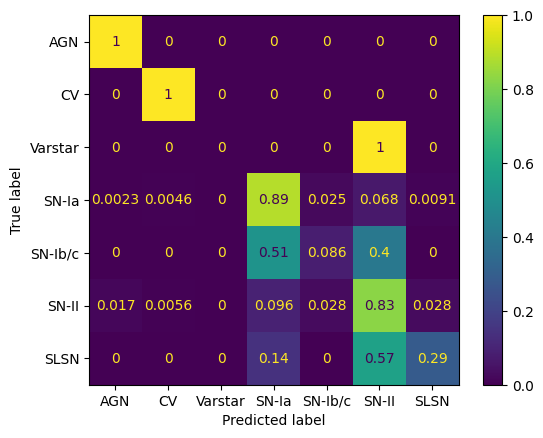

In [10]:
cf = confusion_matrix(df_classified['true'].to_numpy(), df_classified['l2_pred'].to_numpy(), labels=['AGN', 'CV', 'Varstar', 'SN-Ia', 'SN-Ib/c', 'SN-II', 'SLSN'], normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cf, display_labels=['AGN', 'CV', 'Varstar', 'SN-Ia', 'SN-Ib/c', 'SN-II', 'SLSN'])
disp.plot()

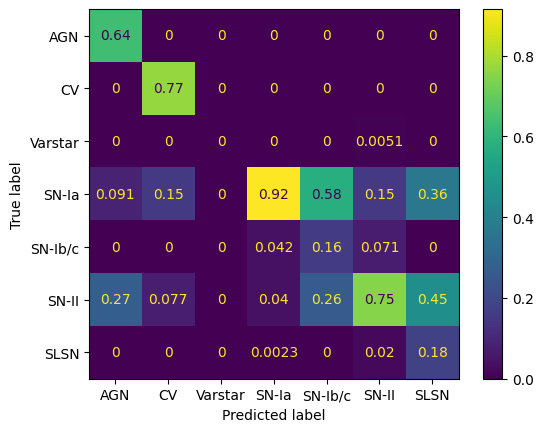

In [11]:
cf = confusion_matrix(df_classified['true'].to_numpy(), df_classified['l2_pred'].to_numpy(), labels=['AGN', 'CV', 'Varstar', 'SN-Ia', 'SN-Ib/c', 'SN-II', 'SLSN'], normalize='pred')

disp = ConfusionMatrixDisplay(confusion_matrix=cf, display_labels=['AGN', 'CV', 'Varstar', 'SN-Ia', 'SN-Ib/c', 'SN-II', 'SLSN'])
disp.plot()

In [12]:
report = classification_report(df_classified['true_1'].to_numpy(), df_classified['l1_pred'].to_numpy(), output_dict=True)

report1 = pd.DataFrame(report).transpose()
print(report1.to_latex(float_format=lambda x: f"{x:.2f}"))

\begin{tabular}{lrrrr}
\toprule
 & precision & recall & f1-score & support \\
\midrule
Persistent & 0.76 & 0.89 & 0.82 & 18.00 \\
Transient & 1.00 & 0.99 & 0.99 & 658.00 \\
accuracy & 0.99 & 0.99 & 0.99 & 0.99 \\
macro avg & 0.88 & 0.94 & 0.91 & 676.00 \\
weighted avg & 0.99 & 0.99 & 0.99 & 676.00 \\
\bottomrule
\end{tabular}



In [13]:
import os

os.makedirs("./Data", exist_ok=True)

from ztfquery import fritz

In [14]:

days = []
for row in tqdm(df_classified.itertuples(), total=len(df_classified)):
    id_ = row.objectId
    classification_date = row.timestamp
    label = row.true

    lc = fritz.download_lightcurve(id_)

    days.append(classification_date - lc.mjd.min())



100%|██████████| 676/676 [03:32<00:00,  3.17it/s]


In [15]:
df_classified['days'] = days

/var/folders/t6/gdw9ytlx48nd402t7_62k3r00000gn/T/ipykernel_3615/2640602016.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_classified['days'] = days


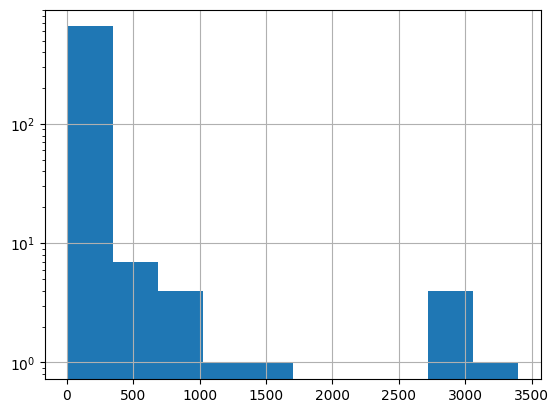

In [16]:
df_classified['days'].hist()
plt.yscale('log')